In [72]:
import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/vincentchidiebere/microfinance-bank-loan-dataset/MF Bank loan Dataset.xlsx'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [73]:
import pandas as pd

df = pd.read_excel('/kaggle/input/datasets/vincentchidiebere/microfinance-bank-loan-dataset/MF Bank loan Dataset.xlsx')
df.head()

,Loan_ID,Mode of application,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,Highest Education,Gender,Guarantor
0,c20160301,Online,COLLECTION,1000,15,2016-09-09,2016-09-23,NaT,76.0,29,college,male,Yes
1,c20160302,Branch,COLLECTION,1000,30,2016-09-09,2016-10-08,NaT,61.0,37,High School or Below,male,No
2,c20160303,Online,COLLECTION,1000,30,2016-09-09,2016-10-08,NaT,61.0,33,High School or Below,male,No
3,c20160304,Online,COLLECTION,800,15,2016-09-09,2016-09-23,NaT,76.0,27,college,male,No
4,c20160305,Online,COLLECTION,800,15,2016-09-09,2016-09-23,NaT,76.0,24,Bachelor Degree,male,No


In [74]:
df.info()
df.isnull().sum()
df['loan_status'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Loan_ID              501 non-null    object        
 1   Mode of application  498 non-null    object        
 2   loan_status          501 non-null    object        
 3   Principal            501 non-null    int64         
 4   terms                501 non-null    int64         
 5   effective_date       501 non-null    datetime64[ns]
 6   due_date             501 non-null    datetime64[ns]
 7   paid_off_time        401 non-null    datetime64[ns]
 8   past_due_days        200 non-null    float64       
 9   age                  501 non-null    int64         
 10  Highest Education    501 non-null    object        
 11  Gender               501 non-null    object        
 12  Guarantor            486 non-null    object        
dtypes: datetime64[ns](3), float64(1), i

loan_status
PAIDOFF               301
COLLECTION            100
COLLECTION_PAIDOFF    100
Name: count, dtype: int64

In [75]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Loan_ID              501 non-null    object        
 1   Mode of application  498 non-null    object        
 2   loan_status          501 non-null    object        
 3   Principal            501 non-null    int64         
 4   terms                501 non-null    int64         
 5   effective_date       501 non-null    datetime64[ns]
 6   due_date             501 non-null    datetime64[ns]
 7   paid_off_time        401 non-null    datetime64[ns]
 8   past_due_days        200 non-null    float64       
 9   age                  501 non-null    int64         
 10  Highest Education    501 non-null    object        
 11  Gender               501 non-null    object        
 12  Guarantor            486 non-null    object        
dtypes: datetime64[ns](3), float64(1), i

Loan_ID                  0
Mode of application      3
loan_status              0
Principal                0
terms                    0
effective_date           0
due_date                 0
paid_off_time          100
past_due_days          301
age                      0
Highest Education        0
Gender                   0
Guarantor               15
dtype: int64

In [76]:
(df.isnull().sum() / len(df)) * 100

Loan_ID                 0.000000
Mode of application     0.598802
loan_status             0.000000
Principal               0.000000
terms                   0.000000
effective_date          0.000000
due_date                0.000000
paid_off_time          19.960080
past_due_days          60.079840
age                     0.000000
Highest Education       0.000000
Gender                  0.000000
Guarantor               2.994012
dtype: float64

In [77]:
df['past_due_days'] = df['past_due_days'].fillna(0)

In [78]:
df.isnull().sum()

Loan_ID                  0
Mode of application      3
loan_status              0
Principal                0
terms                    0
effective_date           0
due_date                 0
paid_off_time          100
past_due_days            0
age                      0
Highest Education        0
Gender                   0
Guarantor               15
dtype: int64

In [79]:
# Step 1: Drop columns with more than 50% missing values
threshold = 50
missing_pct = (df.isnull().sum() / len(df)) * 100
cols_to_drop = missing_pct[missing_pct > threshold].index
df = df.drop(columns=cols_to_drop)
print("Dropped columns:", list(cols_to_drop))

# Step 2: Impute remaining missing values
# Numerical columns -> median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Categorical columns -> mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Check result
df.isnull().sum()

Dropped columns: []


Loan_ID                  0
Mode of application      0
loan_status              0
Principal                0
terms                    0
effective_date           0
due_date                 0
paid_off_time          100
past_due_days            0
age                      0
Highest Education        0
Gender                   0
Guarantor                0
dtype: int64

In [80]:
df = df.drop(columns=['paid_off_time'])
df.isnull().sum()

Loan_ID                0
Mode of application    0
loan_status            0
Principal              0
terms                  0
effective_date         0
due_date               0
past_due_days          0
age                    0
Highest Education      0
Gender                 0
Guarantor              0
dtype: int64

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Loan_ID              501 non-null    object        
 1   Mode of application  501 non-null    object        
 2   loan_status          501 non-null    object        
 3   Principal            501 non-null    int64         
 4   terms                501 non-null    int64         
 5   effective_date       501 non-null    datetime64[ns]
 6   due_date             501 non-null    datetime64[ns]
 7   past_due_days        501 non-null    float64       
 8   age                  501 non-null    int64         
 9   Highest Education    501 non-null    object        
 10  Gender               501 non-null    object        
 11  Guarantor            501 non-null    object        
dtypes: datetime64[ns](2), float64(1), int64(3), object(6)
memory usage: 47.1+ KB


In [82]:
df['loan_status'].value_counts()
df['loan_status'].value_counts(normalize=True) * 100

loan_status
PAIDOFF               60.07984
COLLECTION            19.96008
COLLECTION_PAIDOFF    19.96008
Name: proportion, dtype: float64

In [83]:
df['Principal'].describe()
df.groupby('loan_status')['Principal'].mean()

loan_status
COLLECTION            954.000000
COLLECTION_PAIDOFF    957.000000
PAIDOFF               934.551495
Name: Principal, dtype: float64

In [84]:
df.groupby('loan_status')['terms'].mean()
df['terms'].value_counts()

terms
30    272
15    208
7      21
Name: count, dtype: int64

In [85]:
df.groupby('loan_status')['terms'].mean()

loan_status
COLLECTION            23.850000
COLLECTION_PAIDOFF    23.920000
PAIDOFF               22.093023
Name: terms, dtype: float64

In [86]:
df.groupby('Gender')['loan_status'].value_counts(normalize=True)

Gender  loan_status       
female  PAIDOFF               0.692308
        COLLECTION_PAIDOFF    0.179487
        COLLECTION            0.128205
male    PAIDOFF               0.583924
        COLLECTION            0.212766
        COLLECTION_PAIDOFF    0.203310
Name: proportion, dtype: float64

In [87]:
df.groupby('Highest Education')['loan_status'].value_counts(normalize=True)

Highest Education     loan_status       
Bachelor Degree       PAIDOFF               0.617647
                      COLLECTION_PAIDOFF    0.220588
                      COLLECTION            0.161765
High School or Below  PAIDOFF               0.588517
                      COLLECTION            0.234450
                      COLLECTION_PAIDOFF    0.177033
Master or Above       PAIDOFF               0.750000
                      COLLECTION            0.250000
college               PAIDOFF               0.604545
                      COLLECTION_PAIDOFF    0.218182
                      COLLECTION            0.177273
Name: proportion, dtype: float64

In [88]:
df['Highest Education'].value_counts()

Highest Education
college                 220
High School or Below    209
Bachelor Degree          68
Master or Above           4
Name: count, dtype: int64

In [89]:
df.groupby('Guarantor')['loan_status'].value_counts(normalize=True)

Guarantor  loan_status       
No         PAIDOFF               0.479167
           COLLECTION            0.288690
           COLLECTION_PAIDOFF    0.232143
Yes        PAIDOFF               0.848485
           COLLECTION_PAIDOFF    0.133333
           COLLECTION            0.018182
Name: proportion, dtype: float64

In [90]:
df.groupby('Mode of application')['loan_status'].value_counts(normalize=True)

Mode of application  loan_status       
Branch               PAIDOFF               0.603272
                     COLLECTION_PAIDOFF    0.204499
                     COLLECTION            0.192229
Online               COLLECTION            0.500000
                     PAIDOFF               0.500000
Name: proportion, dtype: float64

In [91]:
df['Mode of application'].value_counts()

Mode of application
Branch    489
Online     12
Name: count, dtype: int64

In [92]:
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,100], labels=['<25','25-35','35-45','45+'])
df.groupby('age_group')['loan_status'].value_counts(normalize=True)

/tmp/ipykernel_58/3759688763.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['loan_status'].value_counts(normalize=True)


age_group  loan_status       
<25        PAIDOFF               0.573333
           COLLECTION            0.240000
           COLLECTION_PAIDOFF    0.186667
25-35      PAIDOFF               0.611285
           COLLECTION            0.194357
           COLLECTION_PAIDOFF    0.194357
35-45      PAIDOFF               0.602151
           COLLECTION_PAIDOFF    0.204301
           COLLECTION            0.193548
45+        PAIDOFF               0.500000
           COLLECTION_PAIDOFF    0.357143
           COLLECTION            0.142857
Name: proportion, dtype: float64

In [93]:
df['age_group'].value_counts()

age_group
25-35    319
35-45     93
<25       75
45+       14
Name: count, dtype: int64

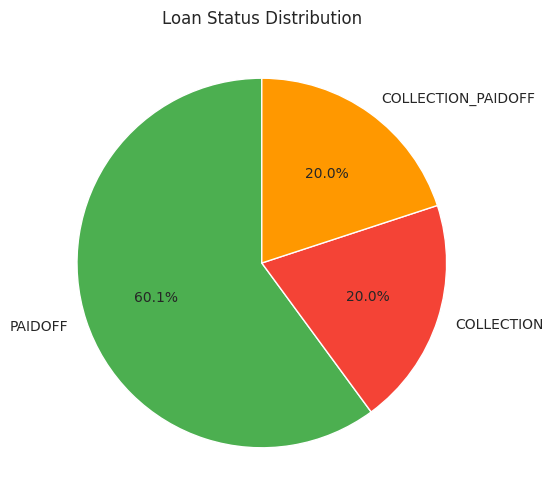

/tmp/ipykernel_58/1724204884.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='Principal', data=df, palette='Set2')


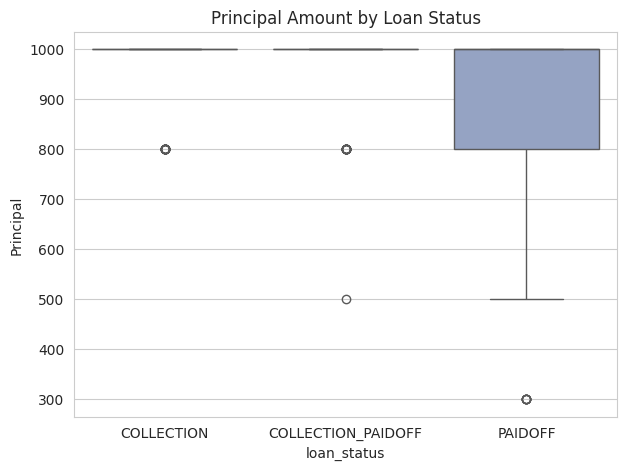

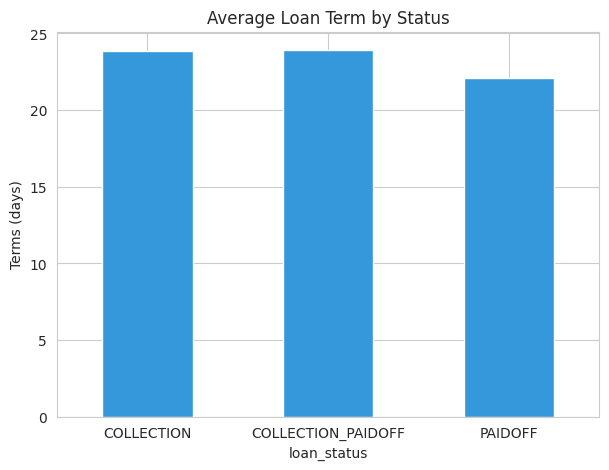

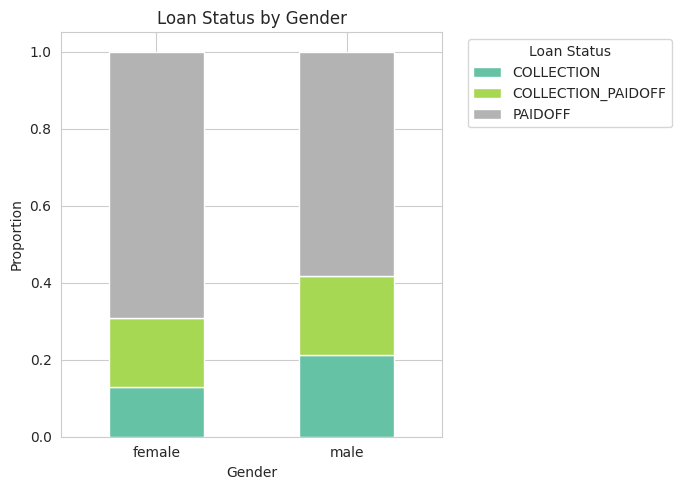

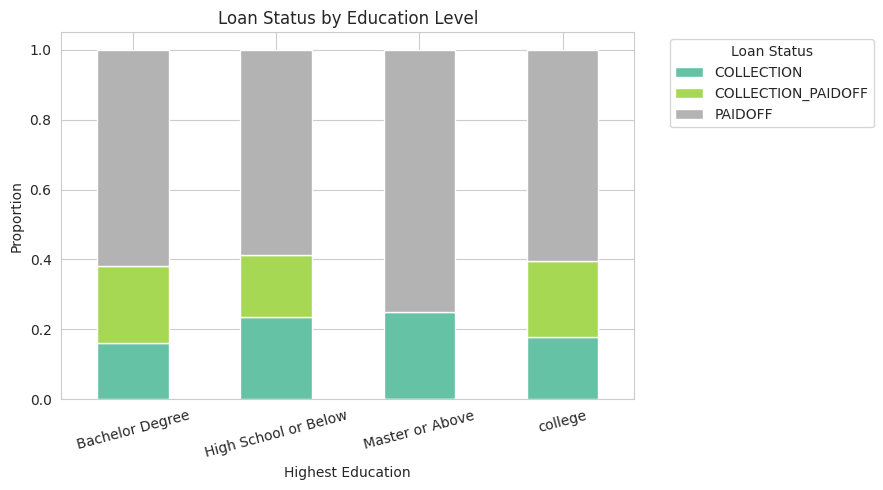

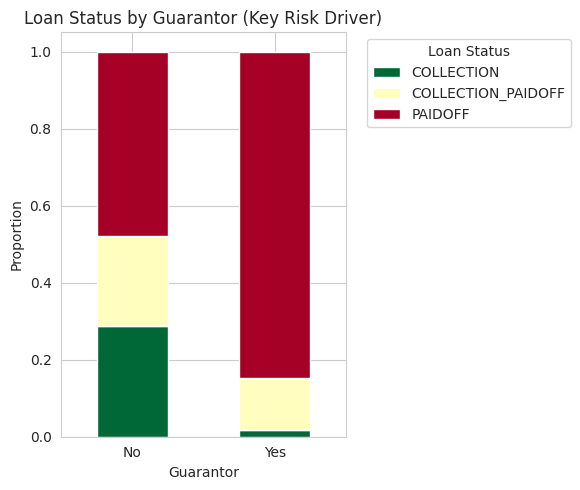

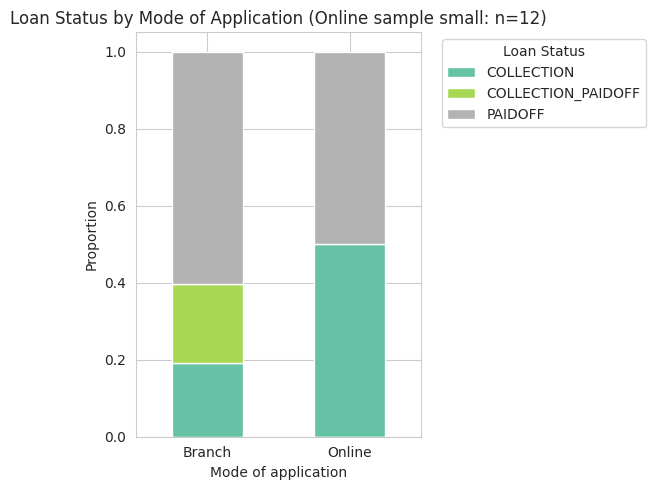

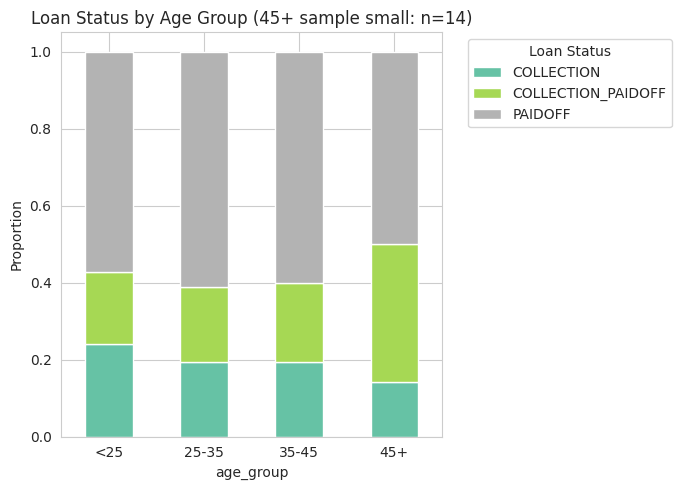

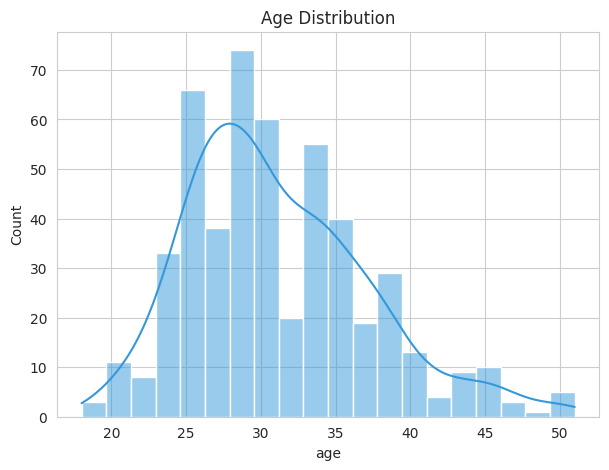

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


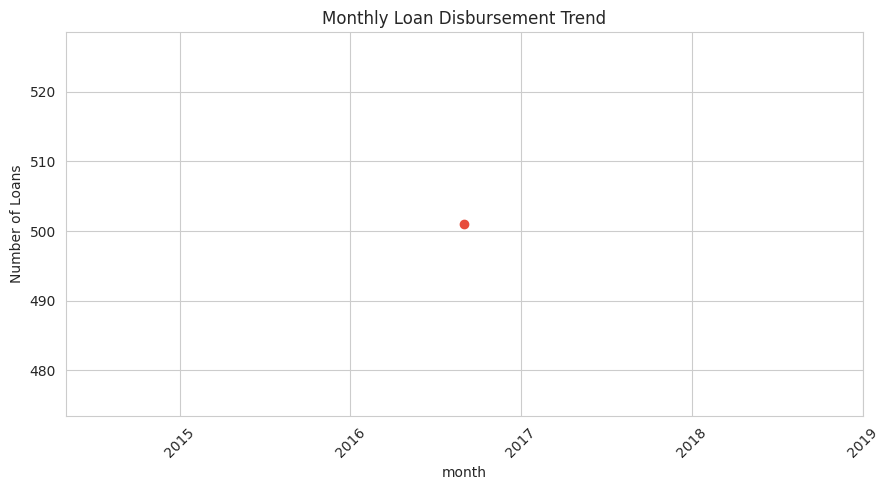

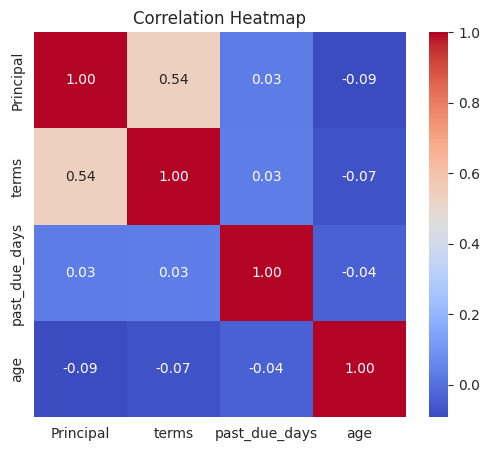

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style('whitegrid')

# 1. Loan status distribution - Pie chart
plt.figure(figsize=(6,6))
df['loan_status'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90,
                                            colors=['#4CAF50','#F44336','#FF9800'])
plt.title('Loan Status Distribution')
plt.ylabel('')
plt.show()

# 2. Principal by loan_status - Box plot
plt.figure(figsize=(7,5))
sns.boxplot(x='loan_status', y='Principal', data=df, palette='Set2')
plt.title('Principal Amount by Loan Status')
plt.show()

# 3. Terms by loan_status - Bar chart
plt.figure(figsize=(7,5))
df.groupby('loan_status')['terms'].mean().plot(kind='bar', color='#3498db')
plt.title('Average Loan Term by Status')
plt.ylabel('Terms (days)')
plt.xticks(rotation=0)
plt.show()

# 4. Gender vs loan_status - Stacked bar chart
pd.crosstab(df['Gender'], df['loan_status'], normalize='index').plot(
    kind='bar', stacked=True, colormap='Set2', figsize=(7,5))
plt.title('Loan Status by Gender')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

# 5. Education vs loan_status - Stacked bar chart
pd.crosstab(df['Highest Education'], df['loan_status'], normalize='index').plot(
    kind='bar', stacked=True, colormap='Set2', figsize=(9,5))
plt.title('Loan Status by Education Level')
plt.ylabel('Proportion')
plt.xticks(rotation=15)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

# 6. Guarantor vs loan_status - Stacked bar chart (headline visual)
pd.crosstab(df['Guarantor'], df['loan_status'], normalize='index').plot(
    kind='bar', stacked=True, colormap='RdYlGn_r', figsize=(6,5))
plt.title('Loan Status by Guarantor (Key Risk Driver)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

# 7. Mode of application vs loan_status - Stacked bar chart
pd.crosstab(df['Mode of application'], df['loan_status'], normalize='index').plot(
    kind='bar', stacked=True, colormap='Set2', figsize=(6,5))
plt.title('Loan Status by Mode of Application (Online sample small: n=12)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

# 8. Age group vs loan_status - Stacked bar chart
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,100], labels=['<25','25-35','35-45','45+'])
pd.crosstab(df['age_group'], df['loan_status'], normalize='index').plot(
    kind='bar', stacked=True, colormap='Set2', figsize=(7,5))
plt.title('Loan Status by Age Group (45+ sample small: n=14)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

# 9. Age distribution - Histogram
plt.figure(figsize=(7,5))
sns.histplot(df['age'], bins=20, kde=True, color='#3498db')
plt.title('Age Distribution')
plt.show()

# 10. Monthly disbursement trend - Line chart
df['month'] = df['effective_date'].dt.to_period('M')
plt.figure(figsize=(9,5))
df.groupby('month').size().plot(kind='line', marker='o', color='#e74c3c')
plt.title('Monthly Loan Disbursement Trend')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 11. Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df[['Principal','terms','past_due_days','age']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Portfolio at Risk (PAR): 39.92%
PAR30: 20.16%
PAR60: 7.58%
PAR90: 0.00%


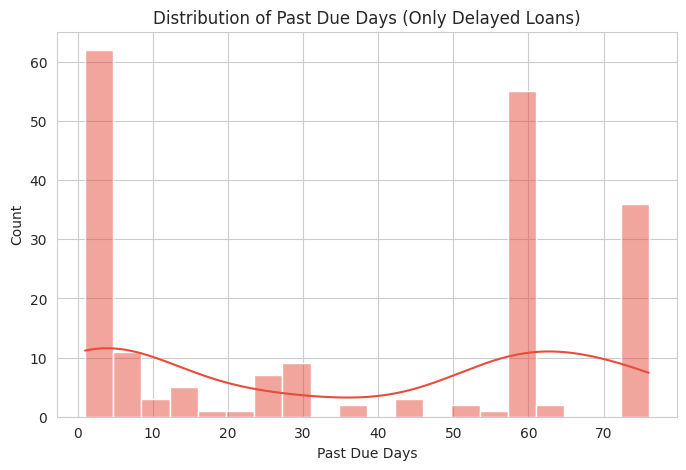

Total rows: 501
Unique Loan_ID: 501


In [95]:
# PAR (Portfolio at Risk) Calculation
par = (df['past_due_days'] > 0).sum() / len(df) * 100
print(f"Portfolio at Risk (PAR): {par:.2f}%")

# PAR by different buckets (30/60/90 days style)
par_30 = (df['past_due_days'] > 30).sum() / len(df) * 100
par_60 = (df['past_due_days'] > 60).sum() / len(df) * 100
par_90 = (df['past_due_days'] > 90).sum() / len(df) * 100

print(f"PAR30: {par_30:.2f}%")
print(f"PAR60: {par_60:.2f}%")
print(f"PAR90: {par_90:.2f}%")

# past_due_days distribution - Histogram
plt.figure(figsize=(8,5))
sns.histplot(df[df['past_due_days'] > 0]['past_due_days'], bins=20, kde=True, color='#e74c3c')
plt.title('Distribution of Past Due Days (Only Delayed Loans)')
plt.xlabel('Past Due Days')
plt.show()

# past_due_days summary statistics
df['Principal'].describe()
df['past_due_days'].describe()

# Check if Loan_ID is unique (client retention check)
print("Total rows:", len(df))
print("Unique Loan_ID:", df['Loan_ID'].nunique())

<Axes: xlabel='Principal'>

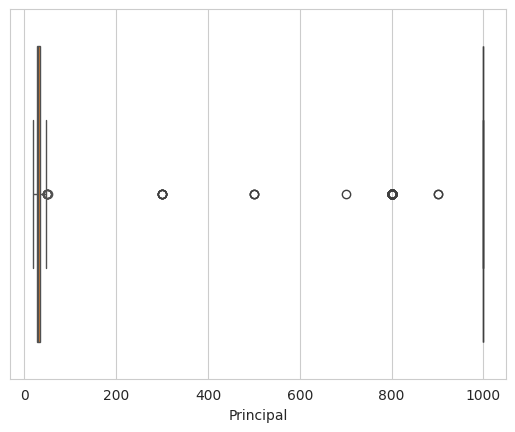

In [96]:
sns.boxplot(x=df['Principal'])
sns.boxplot(x=df['age'])

In [97]:
df.describe()

,Principal,terms,effective_date,due_date,past_due_days,age
count,501.000000,501.000000,501,501,501.000000,501.000000
mean,942.914172,22.808383,2016-09-11 09:57:50.658682624,2016-10-05 08:40:14.371257600,14.375250,31.113772
min,300.000000,7.000000,2016-09-08 00:00:00,2016-09-15 00:00:00,0.000000,18.000000
25%,1000.000000,15.000000,2016-09-11 00:00:00,2016-09-25 00:00:00,0.000000,27.000000
50%,1000.000000,30.000000,2016-09-11 00:00:00,2016-10-10 00:00:00,0.000000,30.000000
75%,1000.000000,30.000000,2016-09-12 00:00:00,2016-10-11 00:00:00,12.000000,35.000000
max,1000.000000,30.000000,2016-09-14 00:00:00,2016-11-12 00:00:00,76.000000,51.000000
std,115.302605,7.999701,NaN,NaN,25.596775,6.078900


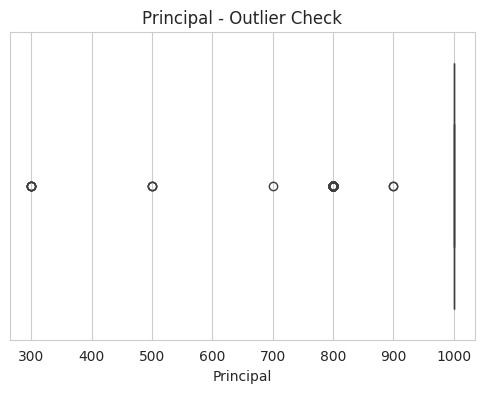

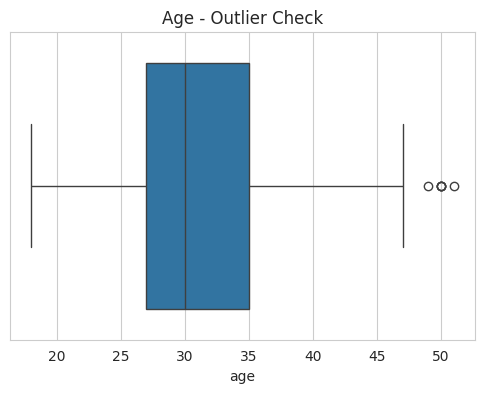

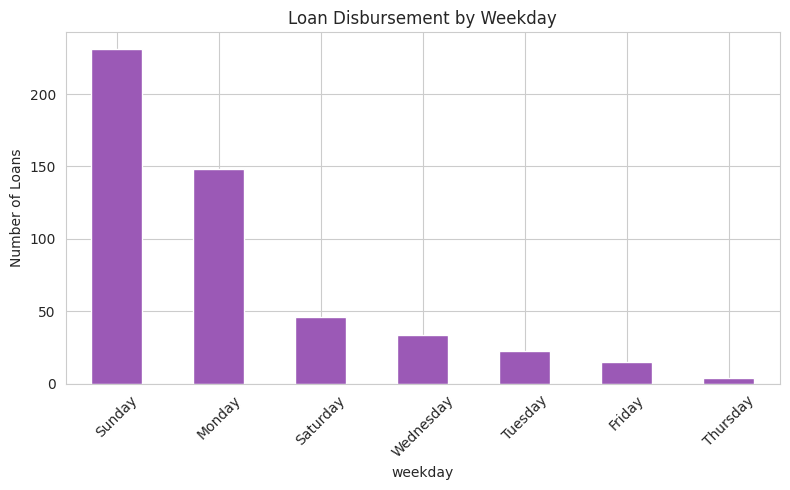

Guarantor  Gender  loan_status       
No         female  PAIDOFF               0.576923
                   COLLECTION_PAIDOFF    0.230769
                   COLLECTION            0.192308
           male    PAIDOFF               0.461268
                   COLLECTION            0.306338
                   COLLECTION_PAIDOFF    0.232394
Yes        female  PAIDOFF               0.923077
                   COLLECTION_PAIDOFF    0.076923
           male    PAIDOFF               0.834532
                   COLLECTION_PAIDOFF    0.143885
                   COLLECTION            0.021583
Name: proportion, dtype: float64

In [98]:
# Outlier detection
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Principal'])
plt.title('Principal - Outlier Check')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title('Age - Outlier Check')
plt.show()

# Correlation table (numeric)
df[['Principal','terms','past_due_days','age']].corr()

# Weekday pattern
df['weekday'] = df['effective_date'].dt.day_name()
plt.figure(figsize=(8,5))
df['weekday'].value_counts().plot(kind='bar', color='#9b59b6')
plt.title('Loan Disbursement by Weekday')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cross-segment: Guarantor + Gender combo risk
df.groupby(['Guarantor','Gender'])['loan_status'].value_counts(normalize=True)

In [99]:
df[['Principal','terms','past_due_days','age']].corr()

,Principal,terms,past_due_days,age
Principal,1.000000,0.535393,0.029025,-0.092012
terms,0.535393,1.000000,0.032066,-0.073827
past_due_days,0.029025,0.032066,1.000000,-0.037794
age,-0.092012,-0.073827,-0.037794,1.000000


In [100]:
df['weekday'].value_counts()

weekday
Sunday       231
Monday       148
Saturday      46
Wednesday     34
Tuesday       23
Friday        15
Thursday       4
Name: count, dtype: int64

loan_status       COLLECTION  COLLECTION_PAIDOFF  PAIDOFF
Guarantor Gender                                         
No        female        19.2                23.1     57.7
          male          30.6                23.2     46.1
Yes       female         0.0                 7.7     92.3
          male           2.2                14.4     83.5


<Figure size 900x600 with 0 Axes>

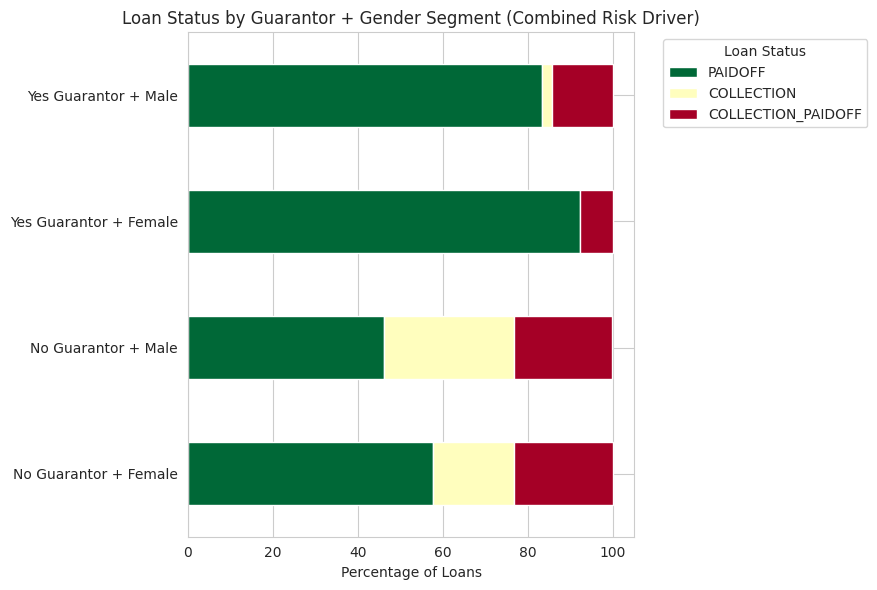

In [101]:
# CROSS-SEGMENT ANALYSIS: GUARANTOR + GENDER vs LOAN STATUS

cross = pd.crosstab([df['Guarantor'], df['Gender']], df['loan_status'], normalize='index') * 100
cross = cross.round(1)
print(cross)

cross_reset = cross.reset_index()
cross_reset['segment'] = cross_reset['Guarantor'] + ' Guarantor + ' + cross_reset['Gender'].str.capitalize()

plt.figure(figsize=(9,6))
cross_reset.set_index('segment')[['PAIDOFF','COLLECTION','COLLECTION_PAIDOFF']].plot(
    kind='barh', stacked=True, colormap='RdYlGn_r', figsize=(9,6))
plt.title('Loan Status by Guarantor + Gender Segment (Combined Risk Driver)')
plt.xlabel('Percentage of Loans')
plt.ylabel('')
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

In [102]:
# Client retention check - is each Loan_ID unique or do clients repeat?
print("Total rows:", len(df))
print("Unique Loan_ID:", df['Loan_ID'].nunique())

Total rows: 501
Unique Loan_ID: 501


In [103]:
from scipy.stats import chi2_contingency

def chi_square_test(col):
    contingency = pd.crosstab(df[col], df['loan_status'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.2f}, p-value={p:.4f}", "-> Significant" if p < 0.05 else "-> Not significant")

for col in ['Guarantor', 'Gender', 'Highest Education', 'Mode of application']:
    chi_square_test(col)

Guarantor: chi2=71.10, p-value=0.0000 -> Significant
Gender: chi2=3.83, p-value=0.1470 -> Not significant
Highest Education: chi2=4.46, p-value=0.6147 -> Not significant
Mode of application: chi2=8.22, p-value=0.0164 -> Significant


In [104]:
df['principal_bucket'] = pd.cut(df['Principal'], bins=[0,500,800,1000], labels=['Small(<=500)','Medium(500-800)','Large(800-1000)'])
df.groupby('principal_bucket')['loan_status'].value_counts(normalize=True)

/tmp/ipykernel_58/514761075.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('principal_bucket')['loan_status'].value_counts(normalize=True)


principal_bucket  loan_status       
Small(<=500)      PAIDOFF               0.888889
                  COLLECTION_PAIDOFF    0.111111
                  COLLECTION            0.000000
Medium(500-800)   PAIDOFF               0.628319
                  COLLECTION            0.203540
                  COLLECTION_PAIDOFF    0.168142
Large(800-1000)   PAIDOFF               0.585752
                  COLLECTION_PAIDOFF    0.211082
                  COLLECTION            0.203166
Name: proportion, dtype: float64

In [105]:
pd.crosstab([df['Guarantor'], df['Highest Education']], df['loan_status'], normalize='index').round(3) * 100

loan_status                     COLLECTION  COLLECTION_PAIDOFF  PAIDOFF
Guarantor Highest Education                                            
No        Bachelor Degree             21.6                25.5     52.9
          High School or Below        36.1                20.3     43.6
          Master or Above             33.3                 0.0     66.7
          college                     24.8                25.5     49.7
Yes       Bachelor Degree              0.0                11.8     88.2
          High School or Below         1.3                13.2     85.5
          Master or Above              0.0                 0.0    100.0
          college                      2.8                14.1     83.1

In [106]:
df.groupby('Guarantor')['past_due_days'].agg(['mean','median','max'])

,mean,median,max
Guarantor,,,
No,20.351190,1.0,76.0
Yes,2.206061,0.0,76.0


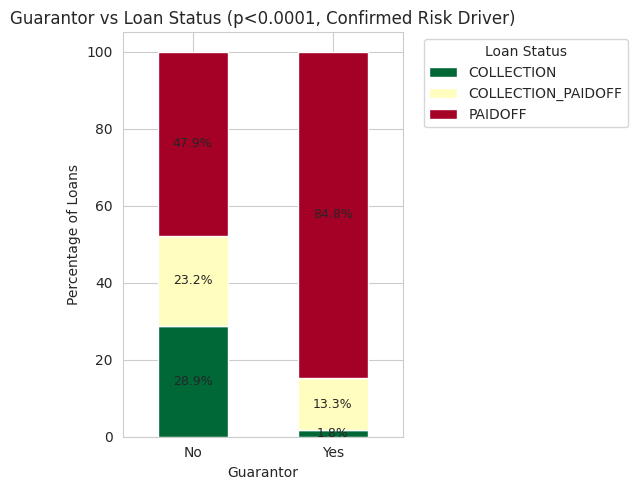

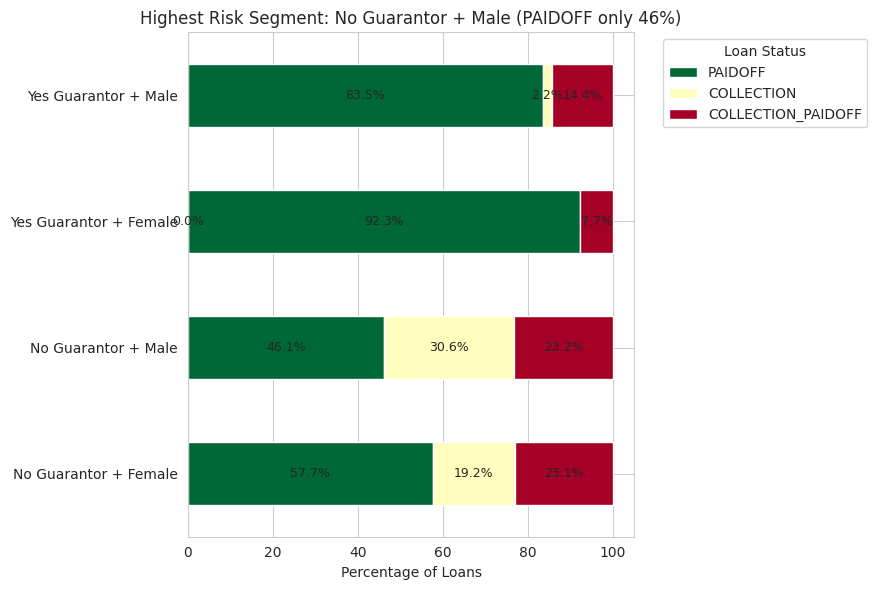

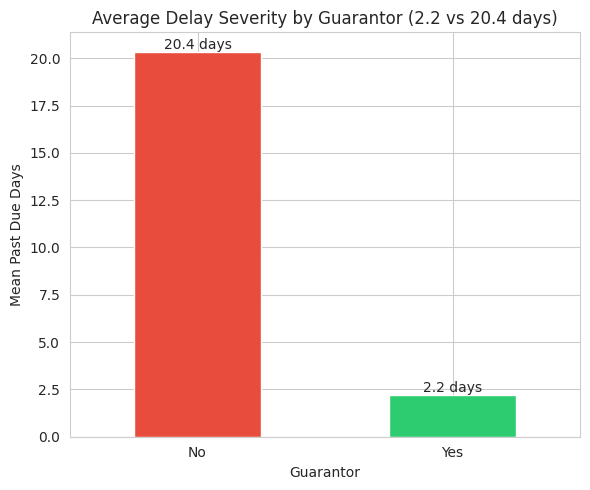

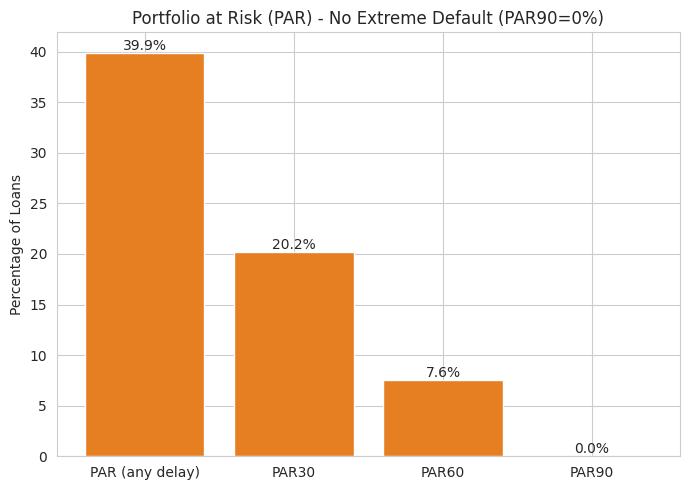

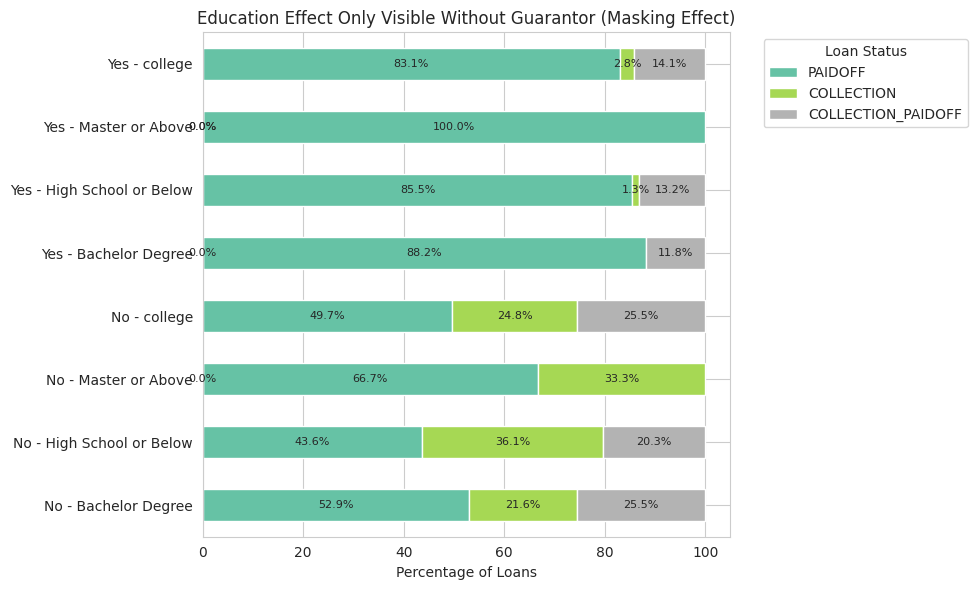

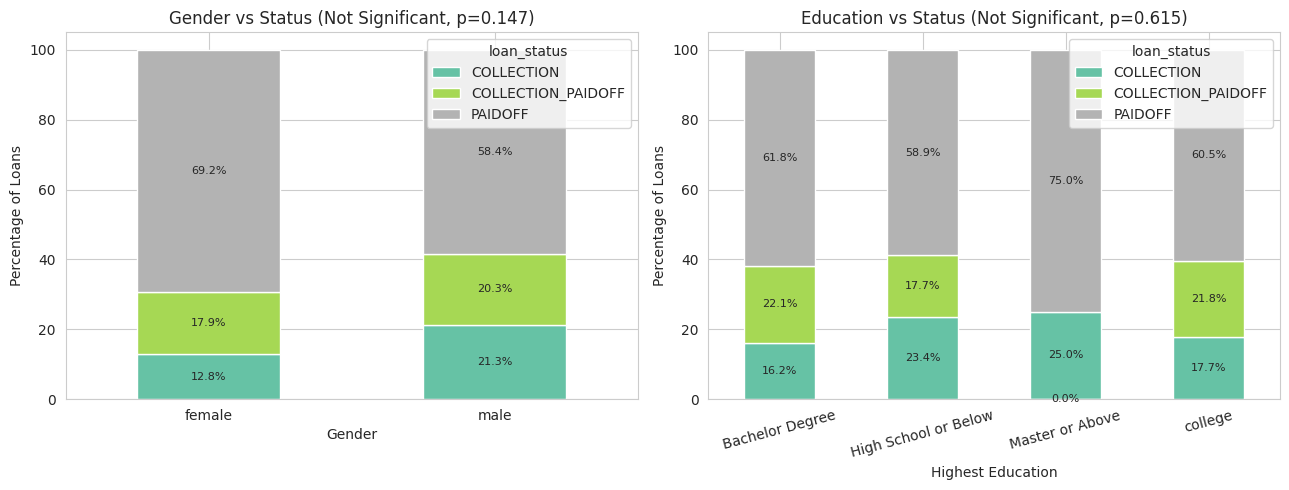

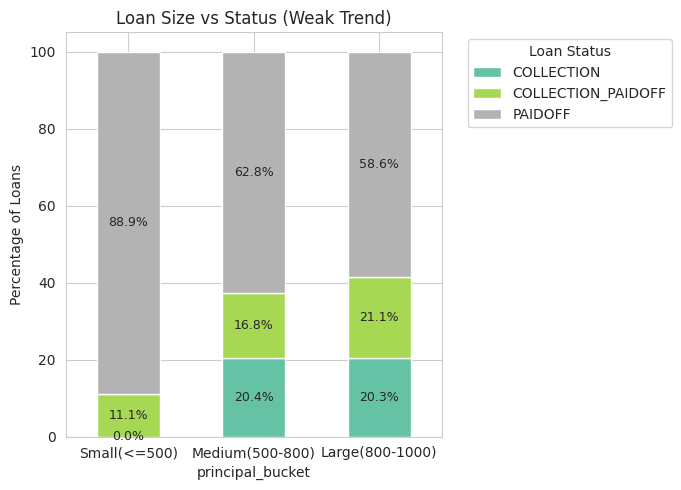

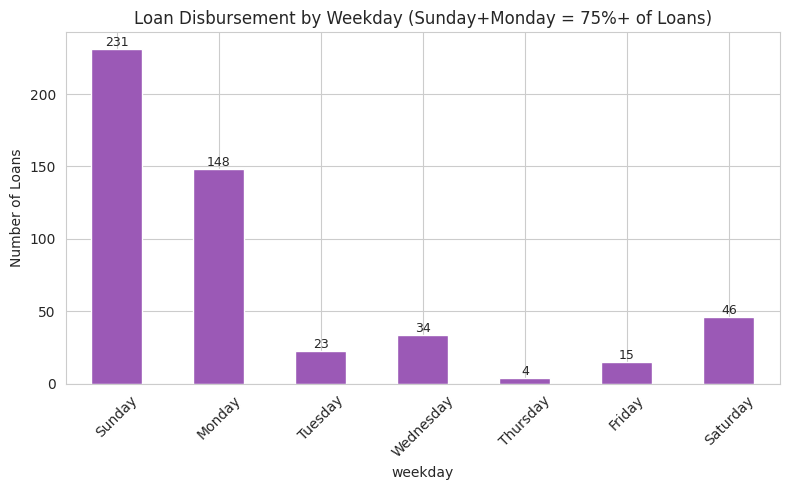

Total rows: 501
Unique Loan_ID: 501
Note: Every loan is a unique client -> retention analysis not possible with this dataset


In [107]:
# ============================================
# SUMMARY VISUALIZATIONS - ALL KEY FINDINGS (FIXED: % SCALE + DATA LABELS)
# ============================================

# 1. Guarantor vs Loan Status
data1 = pd.crosstab(df['Guarantor'], df['loan_status'], normalize='index') * 100
ax = data1.plot(kind='bar', stacked=True, colormap='RdYlGn_r', figsize=(6,5))
plt.title('Guarantor vs Loan Status (p<0.0001, Confirmed Risk Driver)')
plt.ylabel('Percentage of Loans')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
plt.tight_layout()
plt.show()

# 2. Guarantor + Gender combined segment
cross = pd.crosstab([df['Guarantor'], df['Gender']], df['loan_status'], normalize='index') * 100
cross_reset = cross.reset_index()
cross_reset['segment'] = cross_reset['Guarantor'] + ' Guarantor + ' + cross_reset['Gender'].str.capitalize()
ax = cross_reset.set_index('segment')[['PAIDOFF','COLLECTION','COLLECTION_PAIDOFF']].plot(
    kind='barh', stacked=True, colormap='RdYlGn_r', figsize=(9,6))
plt.title('Highest Risk Segment: No Guarantor + Male (PAIDOFF only 46%)')
plt.xlabel('Percentage of Loans')
plt.ylabel('')
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
plt.tight_layout()
plt.show()

# 3. Delay severity by Guarantor (mean past due days)
delay_stats = df.groupby('Guarantor')['past_due_days'].mean()
ax = delay_stats.plot(kind='bar', color=['#e74c3c','#2ecc71'], figsize=(6,5))
plt.title('Average Delay Severity by Guarantor (2.2 vs 20.4 days)')
plt.ylabel('Mean Past Due Days')
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f days', fontsize=10)
plt.tight_layout()
plt.show()

# 4. PAR (Portfolio at Risk) buckets
par_data = {
    'PAR (any delay)': (df['past_due_days'] > 0).sum() / len(df) * 100,
    'PAR30': (df['past_due_days'] > 30).sum() / len(df) * 100,
    'PAR60': (df['past_due_days'] > 60).sum() / len(df) * 100,
    'PAR90': (df['past_due_days'] > 90).sum() / len(df) * 100
}
plt.figure(figsize=(7,5))
bars = plt.bar(par_data.keys(), par_data.values(), color='#e67e22')
plt.title('Portfolio at Risk (PAR) - No Extreme Default (PAR90=0%)')
plt.ylabel('Percentage of Loans')
plt.bar_label(bars, fmt='%.1f%%', fontsize=10)
plt.tight_layout()
plt.show()

# 5. Education effect masked by Guarantor
edu_guarantor = pd.crosstab([df['Guarantor'], df['Highest Education']], df['loan_status'], normalize='index') * 100
edu_reset = edu_guarantor.reset_index()
edu_reset['segment'] = edu_reset['Guarantor'] + ' - ' + edu_reset['Highest Education']
ax = edu_reset.set_index('segment')[['PAIDOFF','COLLECTION','COLLECTION_PAIDOFF']].plot(
    kind='barh', stacked=True, colormap='Set2', figsize=(10,6))
plt.title('Education Effect Only Visible Without Guarantor (Masking Effect)')
plt.xlabel('Percentage of Loans')
plt.ylabel('')
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=8)
plt.tight_layout()
plt.show()

# 6. Gender and Education - weak/not statistically significant
fig, axes = plt.subplots(1, 2, figsize=(13,5))

data_g = pd.crosstab(df['Gender'], df['loan_status'], normalize='index') * 100
data_g.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[0])
axes[0].set_title('Gender vs Status (Not Significant, p=0.147)')
axes[0].set_ylabel('Percentage of Loans')
axes[0].tick_params(axis='x', rotation=0)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', label_type='center', fontsize=8)

data_e = pd.crosstab(df['Highest Education'], df['loan_status'], normalize='index') * 100
data_e.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1])
axes[1].set_title('Education vs Status (Not Significant, p=0.615)')
axes[1].set_ylabel('Percentage of Loans')
axes[1].tick_params(axis='x', rotation=15)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

# 7. Loan amount (Principal) risk trend
data_p = pd.crosstab(df['principal_bucket'], df['loan_status'], normalize='index') * 100
ax = data_p.plot(kind='bar', stacked=True, colormap='Set2', figsize=(7,5))
plt.title('Loan Size vs Status (Weak Trend)')
plt.ylabel('Percentage of Loans')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
plt.tight_layout()
plt.show()

# 8. Weekday disbursement pattern
plt.figure(figsize=(8,5))
weekday_data = df['weekday'].value_counts().reindex(
    ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'])
bars = weekday_data.plot(kind='bar', color='#9b59b6')
plt.title('Loan Disbursement by Weekday (Sunday+Monday = 75%+ of Loans)')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45)
for c in bars.containers:
    bars.bar_label(c, fontsize=9)
plt.tight_layout()
plt.show()

# 9. Client retention check (limitation note)
print("Total rows:", len(df))
print("Unique Loan_ID:", df['Loan_ID'].nunique())
print("Note: Every loan is a unique client -> retention analysis not possible with this dataset")

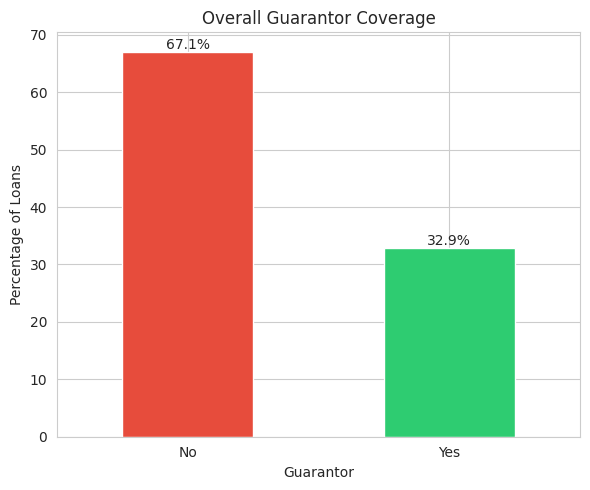

Number of mismatched rows: 501
month
2016-09    60.07984
Freq: M, Name: loan_status, dtype: float64


/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


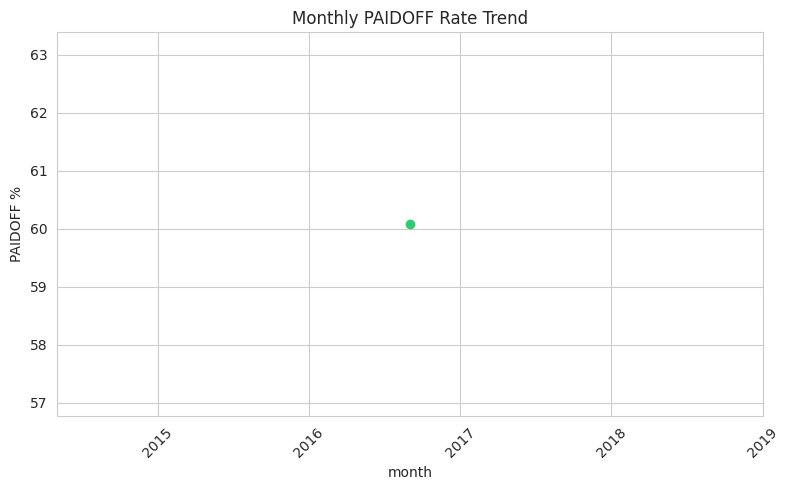

loan_status                 COLLECTION  COLLECTION_PAIDOFF     PAIDOFF
principal_bucket Guarantor                                            
Small(<=500)     No           0.000000           25.000000   75.000000
                 Yes          0.000000            0.000000  100.000000
Medium(500-800)  No          29.333333           21.333333   49.333333
                 Yes          2.631579            7.894737   89.473684
Large(800-1000)  No          29.182879           23.735409   47.081712
                 Yes          1.639344           15.573770   82.786885


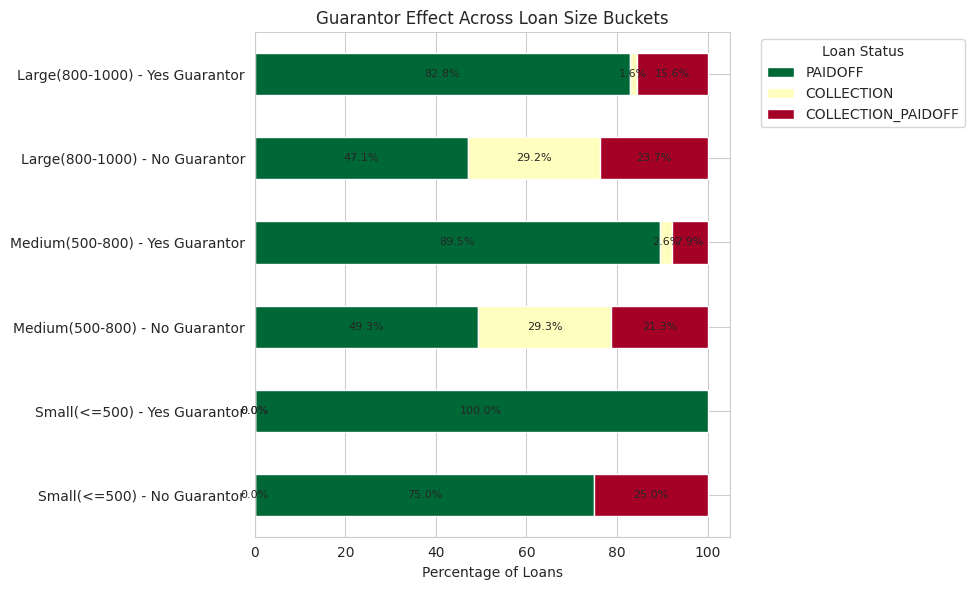

Duplicate rows: 0
Duplicate Loan_IDs: 0
age_group
<25      942.666667
25-35    948.902821
35-45    929.032258
45+      900.000000
Name: Principal, dtype: float64


/tmp/ipykernel_58/625259377.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_principal = df.groupby('age_group')['Principal'].mean()


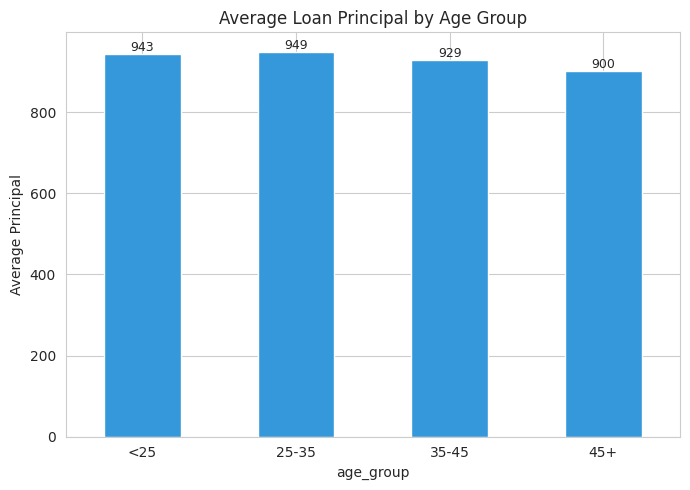

In [108]:
# ============================================
# 1. GUARANTOR OVERALL DISTRIBUTION
# ============================================
df['Guarantor'].value_counts()
df['Guarantor'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,5))
bars = (df['Guarantor'].value_counts(normalize=True) * 100).plot(kind='bar', color=['#e74c3c','#2ecc71'])
plt.title('Overall Guarantor Coverage')
plt.ylabel('Percentage of Loans')
plt.xticks(rotation=0)
for c in bars.containers:
    bars.bar_label(c, fmt='%.1f%%', fontsize=10)
plt.tight_layout()
plt.show()

# ============================================
# 2. DATA CONSISTENCY CHECK (due_date - effective_date vs terms)
# ============================================
df['calculated_days'] = (df['due_date'] - df['effective_date']).dt.days
df['terms_mismatch'] = df['calculated_days'] != df['terms']
print("Number of mismatched rows:", df['terms_mismatch'].sum())
df[df['terms_mismatch']][['Loan_ID','effective_date','due_date','terms','calculated_days']]

# ============================================
# 3. MONTHLY RISK TREND (PAIDOFF % by month)
# ============================================
monthly_risk = df.groupby('month')['loan_status'].apply(
    lambda x: (x == 'PAIDOFF').sum() / len(x) * 100
)
print(monthly_risk)

plt.figure(figsize=(8,5))
monthly_risk.plot(kind='line', marker='o', color='#2ecc71')
plt.title('Monthly PAIDOFF Rate Trend')
plt.ylabel('PAIDOFF %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================
# 4. GUARANTOR + PRINCIPAL BUCKET COMBO
# ============================================
combo = pd.crosstab([df['principal_bucket'], df['Guarantor']], df['loan_status'], normalize='index') * 100
print(combo)

combo_reset = combo.reset_index()
combo_reset['segment'] = combo_reset['principal_bucket'].astype(str) + ' - ' + combo_reset['Guarantor'] + ' Guarantor'
ax = combo_reset.set_index('segment')[['PAIDOFF','COLLECTION','COLLECTION_PAIDOFF']].plot(
    kind='barh', stacked=True, colormap='RdYlGn_r', figsize=(10,6))
plt.title('Guarantor Effect Across Loan Size Buckets')
plt.xlabel('Percentage of Loans')
plt.ylabel('')
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=8)
plt.tight_layout()
plt.show()

# ============================================
# 5. DUPLICATE / DATA INTEGRITY CHECK
# ============================================
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Loan_IDs:", df['Loan_ID'].duplicated().sum())

# ============================================
# 6. AGE GROUP vs PRINCIPAL (do younger clients borrow more/less?)
# ============================================
age_principal = df.groupby('age_group')['Principal'].mean()
print(age_principal)

plt.figure(figsize=(7,5))
bars = age_principal.plot(kind='bar', color='#3498db')
plt.title('Average Loan Principal by Age Group')
plt.ylabel('Average Principal')
plt.xticks(rotation=0)
for c in bars.containers:
    bars.bar_label(c, fmt='%.0f', fontsize=9)
plt.tight_layout()
plt.show()

In [109]:
df['Guarantor'].value_counts(normalize=True) * 100

Guarantor
No     67.065868
Yes    32.934132
Name: proportion, dtype: float64

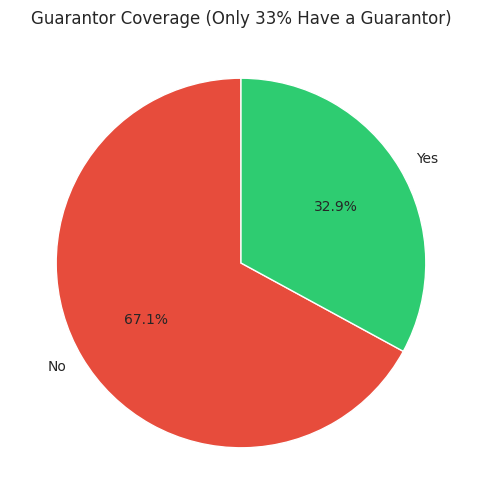

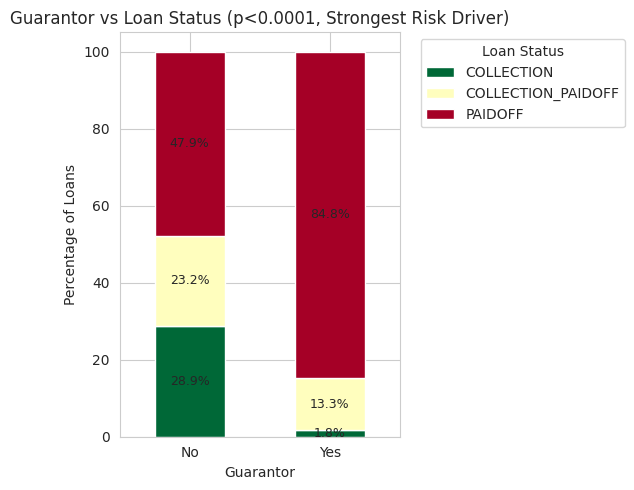

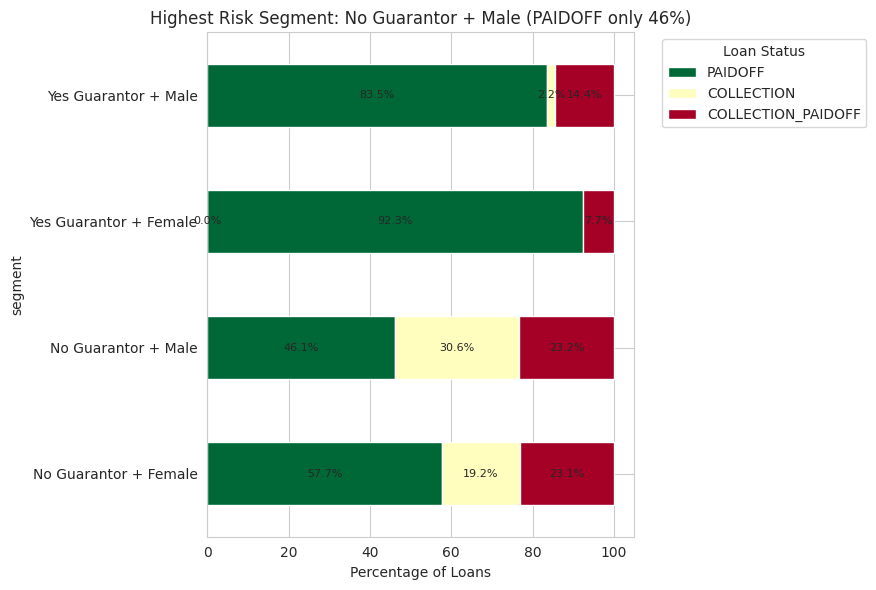

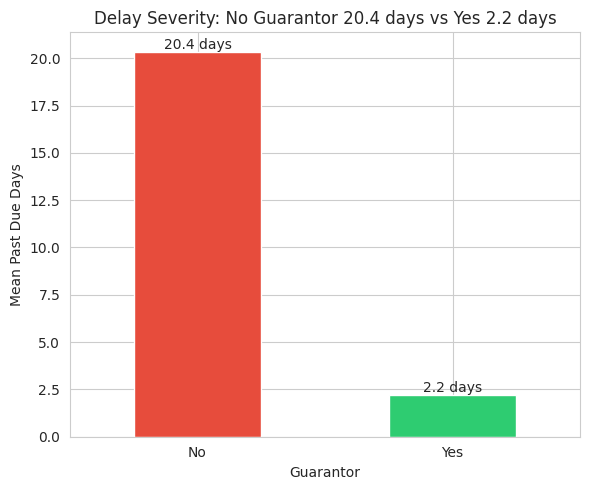

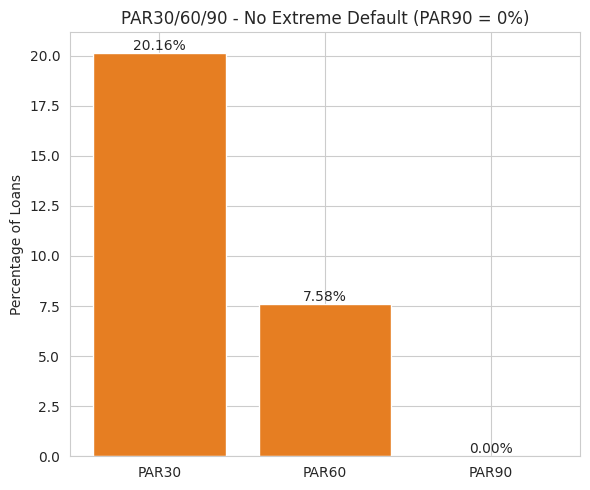

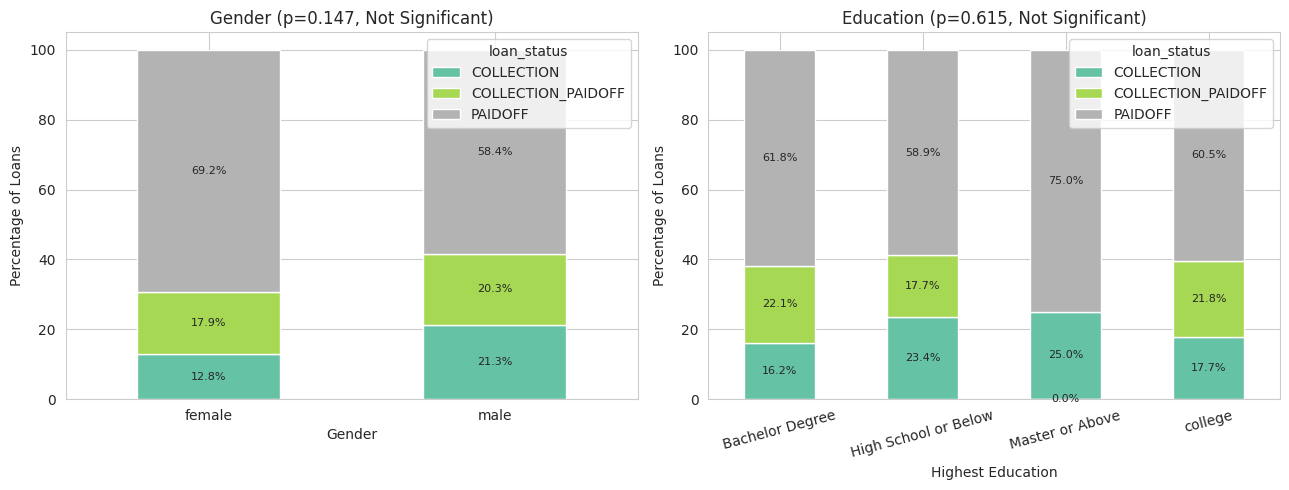

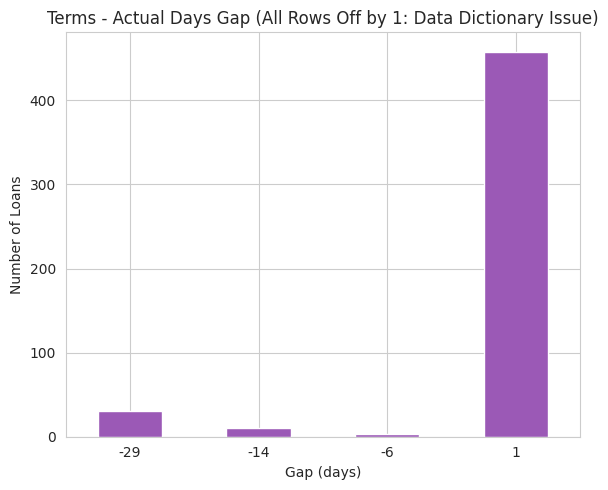

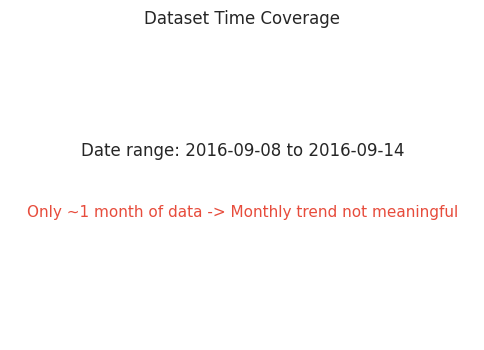

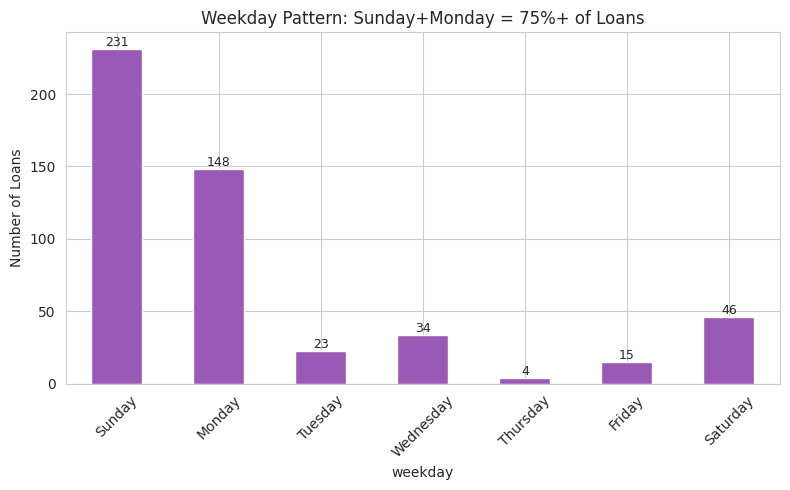

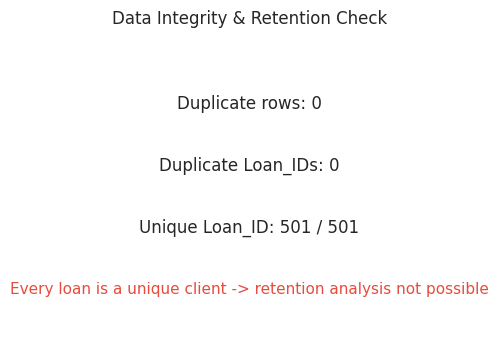

In [110]:
# ============================================
# 1. Guarantor Coverage (Overall Distribution)
# ============================================
plt.figure(figsize=(6,6))
guarantor_dist = df['Guarantor'].value_counts()
plt.pie(guarantor_dist, labels=guarantor_dist.index, autopct='%1.1f%%',
        colors=['#e74c3c','#2ecc71'], startangle=90)
plt.title('Guarantor Coverage (Only 33% Have a Guarantor)')
plt.show()

# ============================================
# 2. Guarantor = Strongest Risk Driver (with p-value in title)
# ============================================
data2 = pd.crosstab(df['Guarantor'], df['loan_status'], normalize='index') * 100
ax = data2.plot(kind='bar', stacked=True, colormap='RdYlGn_r', figsize=(6,5))
plt.title('Guarantor vs Loan Status (p<0.0001, Strongest Risk Driver)')
plt.ylabel('Percentage of Loans')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
plt.tight_layout()
plt.show()

# ============================================
# 3. No Guarantor + Male = Highest Risk Segment
# ============================================
cross = pd.crosstab([df['Guarantor'], df['Gender']], df['loan_status'], normalize='index') * 100
cross_reset = cross.reset_index()
cross_reset['segment'] = cross_reset['Guarantor'] + ' Guarantor + ' + cross_reset['Gender'].str.capitalize()
ax = cross_reset.set_index('segment')[['PAIDOFF','COLLECTION','COLLECTION_PAIDOFF']].plot(
    kind='barh', stacked=True, colormap='RdYlGn_r', figsize=(9,6))
plt.title('Highest Risk Segment: No Guarantor + Male (PAIDOFF only 46%)')
plt.xlabel('Percentage of Loans')
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=8)
plt.tight_layout()
plt.show()

# ============================================
# 4. Delay Severity by Guarantor
# ============================================
delay_stats = df.groupby('Guarantor')['past_due_days'].mean()
ax = delay_stats.plot(kind='bar', color=['#e74c3c','#2ecc71'], figsize=(6,5))
plt.title('Delay Severity: No Guarantor 20.4 days vs Yes 2.2 days')
plt.ylabel('Mean Past Due Days')
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f days', fontsize=10)
plt.tight_layout()
plt.show()

# ============================================
# 5. PAR30 / PAR60 / PAR90
# ============================================
par_data = {
    'PAR30': (df['past_due_days'] > 30).sum() / len(df) * 100,
    'PAR60': (df['past_due_days'] > 60).sum() / len(df) * 100,
    'PAR90': (df['past_due_days'] > 90).sum() / len(df) * 100
}
plt.figure(figsize=(6,5))
bars = plt.bar(par_data.keys(), par_data.values(), color='#e67e22')
plt.title('PAR30/60/90 - No Extreme Default (PAR90 = 0%)')
plt.ylabel('Percentage of Loans')
plt.bar_label(bars, fmt='%.2f%%', fontsize=10)
plt.tight_layout()
plt.show()

# ============================================
# 6. Gender / Education - Not Statistically Significant
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(13,5))
data_g = pd.crosstab(df['Gender'], df['loan_status'], normalize='index') * 100
data_g.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[0])
axes[0].set_title('Gender (p=0.147, Not Significant)')
axes[0].set_ylabel('Percentage of Loans')
axes[0].tick_params(axis='x', rotation=0)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', label_type='center', fontsize=8)

data_e = pd.crosstab(df['Highest Education'], df['loan_status'], normalize='index') * 100
data_e.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1])
axes[1].set_title('Education (p=0.615, Not Significant)')
axes[1].set_ylabel('Percentage of Loans')
axes[1].tick_params(axis='x', rotation=15)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', label_type='center', fontsize=8)
plt.tight_layout()
plt.show()

# ============================================
# 7. Terms vs Actual Date Gap (Data Quality Note)
# ============================================
plt.figure(figsize=(6,5))
gap = df['terms'] - df['calculated_days']
gap.value_counts().sort_index().plot(kind='bar', color='#9b59b6')
plt.title('Terms - Actual Days Gap (All Rows Off by 1: Data Dictionary Issue)')
plt.xlabel('Gap (days)')
plt.ylabel('Number of Loans')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================
# 8. Dataset Duration (Single Month Note)
# ============================================
plt.figure(figsize=(6,4))
plt.text(0.5, 0.6, f"Date range: {df['effective_date'].min().date()} to {df['effective_date'].max().date()}",
          ha='center', fontsize=12)
plt.text(0.5, 0.4, "Only ~1 month of data -> Monthly trend not meaningful", ha='center', fontsize=11, color='#e74c3c')
plt.axis('off')
plt.title('Dataset Time Coverage')
plt.show()

# ============================================
# 9. Weekday Disbursement Pattern
# ============================================
plt.figure(figsize=(8,5))
weekday_data = df['weekday'].value_counts().reindex(
    ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'])
bars = weekday_data.plot(kind='bar', color='#9b59b6')
plt.title('Weekday Pattern: Sunday+Monday = 75%+ of Loans')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45)
for c in bars.containers:
    bars.bar_label(c, fontsize=9)
plt.tight_layout()
plt.show()

# ============================================
# 10. Data Integrity Summary (Duplicate + Retention Note)
# ============================================
plt.figure(figsize=(6,4))
plt.text(0.5, 0.75, f"Duplicate rows: {df.duplicated().sum()}", ha='center', fontsize=12)
plt.text(0.5, 0.55, f"Duplicate Loan_IDs: {df['Loan_ID'].duplicated().sum()}", ha='center', fontsize=12)
plt.text(0.5, 0.35, f"Unique Loan_ID: {df['Loan_ID'].nunique()} / {len(df)}", ha='center', fontsize=12)
plt.text(0.5, 0.15, "Every loan is a unique client -> retention analysis not possible", ha='center', fontsize=11, color='#e74c3c')
plt.axis('off')
plt.title('Data Integrity & Retention Check')
plt.show()

In [111]:
from scipy.stats import ttest_ind

group_no = df[df['Guarantor'] == 'No']['past_due_days']
group_yes = df[df['Guarantor'] == 'Yes']['past_due_days']

t_stat, p_value = ttest_ind(group_no, group_yes)
print(f"t-statistic: {t_stat:.2f}, p-value: {p_value:.4f}")
print("Significant" if p_value < 0.05 else "Not significant")

t-statistic: 7.90, p-value: 0.0000
Significant


In [112]:
from scipy.stats import f_oneway

groups = [df[df['age_group'] == g]['Principal'].dropna() for g in df['age_group'].cat.categories]
f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")
print("Significant" if p_value < 0.05 else "Not significant")

F-statistic: 1.39, p-value: 0.2463
Not significant


In [113]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Principal'], df['terms'])
print(f"Correlation: {corr:.3f}, p-value: {p_value:.4f}")
print("Significant" if p_value < 0.05 else "Not significant")

Correlation: 0.535, p-value: 0.0000
Significant


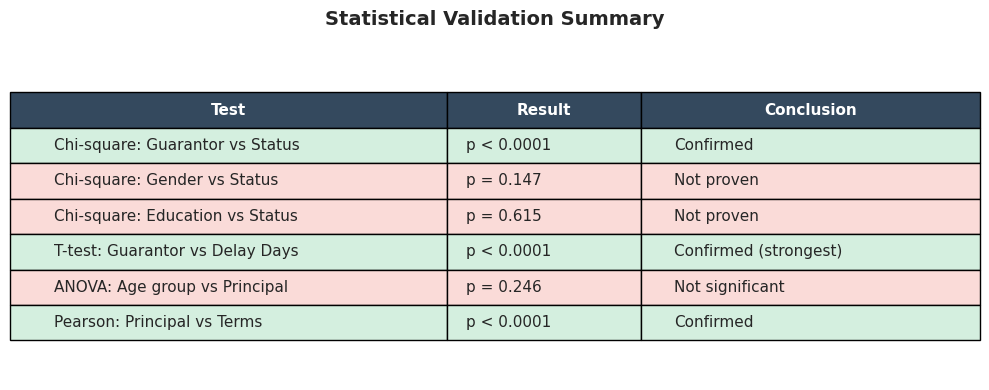

In [114]:
import matplotlib.pyplot as plt

# Statistical validation summary table
results = [
    ["Chi-square: Guarantor vs Status", "p < 0.0001", "Confirmed"],
    ["Chi-square: Gender vs Status", "p = 0.147", "Not proven"],
    ["Chi-square: Education vs Status", "p = 0.615", "Not proven"],
    ["T-test: Guarantor vs Delay Days", "p < 0.0001", "Confirmed (strongest)"],
    ["ANOVA: Age group vs Principal", "p = 0.246", "Not significant"],
    ["Pearson: Principal vs Terms", "p < 0.0001", "Confirmed"]
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=results,
    colLabels=["Test", "Result", "Conclusion"],
    cellLoc='left',
    loc='center',
    colWidths=[0.45, 0.2, 0.35]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Color header
for i in range(3):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(color='white', fontweight='bold')

# Color rows based on significance (green = confirmed, red = not significant)
for row_idx, row in enumerate(results, start=1):
    color = '#d4efdf' if 'Confirmed' in row[2] else '#fadbd8'
    for col_idx in range(3):
        table[(row_idx, col_idx)].set_facecolor(color)

plt.title('Statistical Validation Summary', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

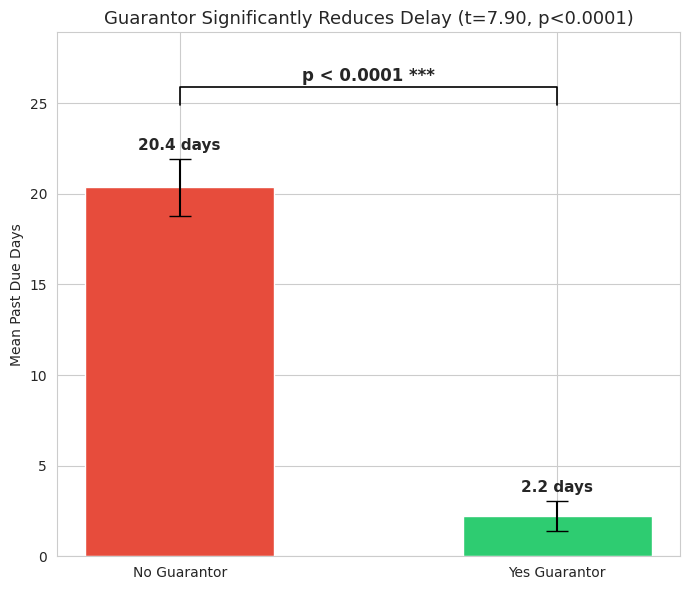

In [115]:
from scipy.stats import ttest_ind
import numpy as np

# T-test: Guarantor vs past_due_days (the strongest proven finding)
group_no = df[df['Guarantor'] == 'No']['past_due_days']
group_yes = df[df['Guarantor'] == 'Yes']['past_due_days']
t_stat, p_value = ttest_ind(group_no, group_yes)

means = [group_no.mean(), group_yes.mean()]
sems = [group_no.sem(), group_yes.sem()]  # standard error for error bars

fig, ax = plt.subplots(figsize=(7,6))
bars = ax.bar(['No Guarantor', 'Yes Guarantor'], means, yerr=sems, capsize=8,
               color=['#e74c3c','#2ecc71'], width=0.5)

# Add mean value labels on bars
for i, (bar, mean) in enumerate(zip(bars, means)):
    ax.text(bar.get_x() + bar.get_width()/2, mean + sems[i] + 0.5,
             f'{mean:.1f} days', ha='center', fontsize=11, fontweight='bold')

# Significance bracket between bars
y_max = max(means) + max(sems) + 3
ax.plot([0, 0, 1, 1], [y_max, y_max+1, y_max+1, y_max], color='black', linewidth=1.2)
sig_text = f"p < 0.0001 ***" if p_value < 0.0001 else f"p = {p_value:.4f}"
ax.text(0.5, y_max+1.3, sig_text, ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Mean Past Due Days')
ax.set_title(f'Guarantor Significantly Reduces Delay (t={t_stat:.2f}, p<0.0001)', fontsize=13)
ax.set_ylim(0, y_max+4)
plt.tight_layout()
plt.show()

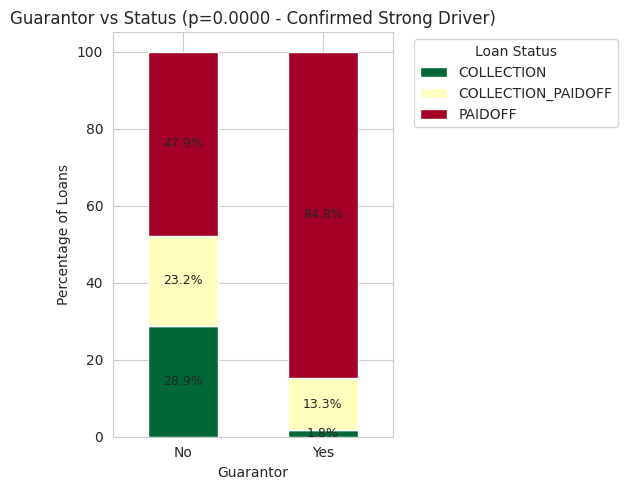

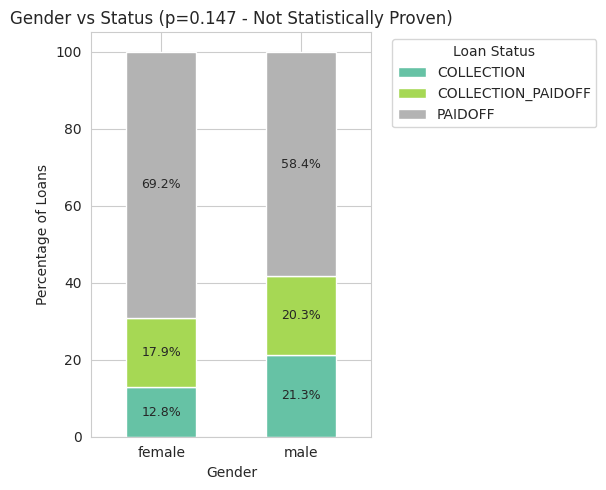

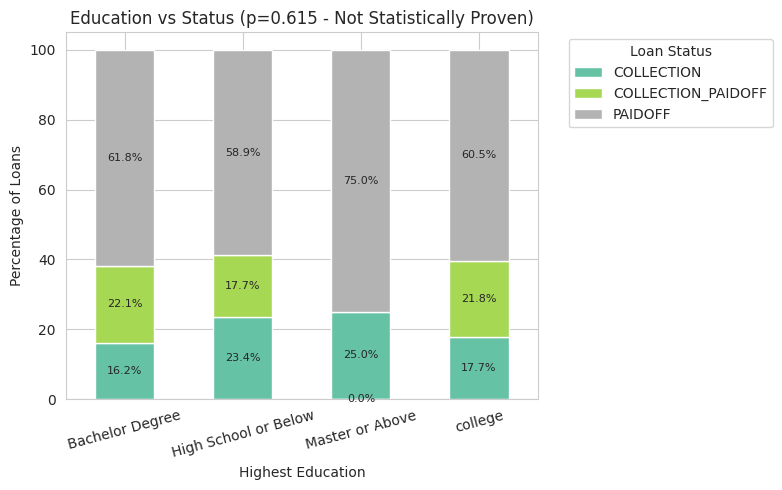

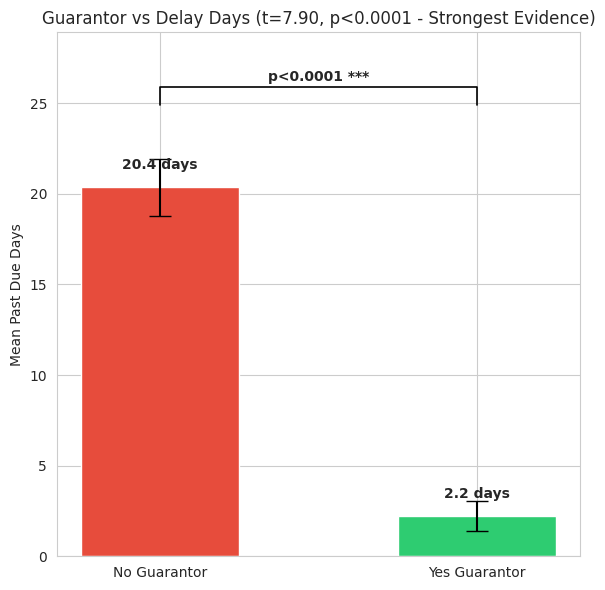

In [116]:
from scipy.stats import chi2_contingency, ttest_ind, f_oneway, pearsonr

# ============================================
# 1. Guarantor vs Status - CONFIRMED (Chi-square)
# ============================================
data1 = pd.crosstab(df['Guarantor'], df['loan_status'], normalize='index') * 100
chi2, p1, _, _ = chi2_contingency(pd.crosstab(df['Guarantor'], df['loan_status']))
ax = data1.plot(kind='bar', stacked=True, colormap='RdYlGn_r', figsize=(6,5))
plt.title(f'Guarantor vs Status (p={p1:.4f} - Confirmed Strong Driver)')
plt.ylabel('Percentage of Loans')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
plt.tight_layout()
plt.show()

# ============================================
# 2. Gender vs Status - NOT PROVEN (Chi-square)
# ============================================
data2 = pd.crosstab(df['Gender'], df['loan_status'], normalize='index') * 100
chi2, p2, _, _ = chi2_contingency(pd.crosstab(df['Gender'], df['loan_status']))
ax = data2.plot(kind='bar', stacked=True, colormap='Set2', figsize=(6,5))
plt.title(f'Gender vs Status (p={p2:.3f} - Not Statistically Proven)')
plt.ylabel('Percentage of Loans')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
plt.tight_layout()
plt.show()

# ============================================
# 3. Education vs Status - NOT PROVEN (Chi-square)
# ============================================
data3 = pd.crosstab(df['Highest Education'], df['loan_status'], normalize='index') * 100
chi2, p3, _, _ = chi2_contingency(pd.crosstab(df['Highest Education'], df['loan_status']))
ax = data3.plot(kind='bar', stacked=True, colormap='Set2', figsize=(8,5))
plt.title(f'Education vs Status (p={p3:.3f} - Not Statistically Proven)')
plt.ylabel('Percentage of Loans')
plt.xticks(rotation=15)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05,1))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=8)
plt.tight_layout()
plt.show()

# ============================================
# 4. Guarantor vs Delay Days - STRONGEST CONFIRMED (T-test)
# ============================================
group_no = df[df['Guarantor'] == 'No']['past_due_days']
group_yes = df[df['Guarantor'] == 'Yes']['past_due_days']
t_stat, p4 = ttest_ind(group_no, group_yes)

means = [group_no.mean(), group_yes.mean()]
sems = [group_no.sem(), group_yes.sem()]
fig, ax = plt.subplots(figsize=(6,6))
bars = ax.bar(['No Guarantor', 'Yes Guarantor'], means, yerr=sems, capsize=8, color=['#e74c3c','#2ecc71'], width=0.5)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 1, f'{mean:.1f} days', ha='center', fontweight='bold')
y_max = max(means) + max(sems) + 3
ax.plot([0,0,1,1], [y_max, y_max+1, y_max+1, y_max], color='black', linewidth=1.2)
ax.text(0.5, y_max+1.3, f'p<0.0001 ***', ha='center', fontweight='bold')
ax.set_ylabel('Mean Past Due Days')
ax.set_title(f'Guarantor vs Delay Days (t={t_stat:.2f}, p<0.0001 - Strongest Evidence)')
ax.set_ylim(0, y_max+4)
plt.tight_layout()
plt.show()

# ============================================
# 5. Age Group vs

            PAIDOFF %  Count
weekday                     
Sunday      51.515152    231
Monday      65.540541    148
Tuesday    100.000000     23
Wednesday  100.000000     34
Thursday   100.000000      4
Friday      33.333333     15
Saturday    41.304348     46


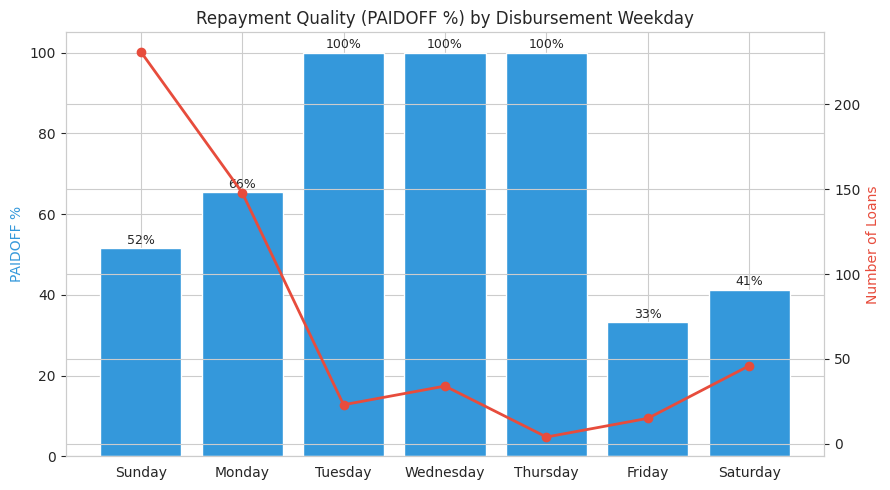

In [117]:
# Weekday-wise risk % (does the day of disbursement affect repayment quality?)
weekday_risk = df.groupby('weekday')['loan_status'].apply(
    lambda x: (x == 'PAIDOFF').sum() / len(x) * 100
).reindex(['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'])

weekday_count = df['weekday'].value_counts().reindex(
    ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'])

print(pd.DataFrame({'PAIDOFF %': weekday_risk, 'Count': weekday_count}))

fig, ax1 = plt.subplots(figsize=(9,5))
bars = ax1.bar(weekday_risk.index, weekday_risk.values, color='#3498db')
ax1.set_ylabel('PAIDOFF %', color='#3498db')
ax1.set_title('Repayment Quality (PAIDOFF %) by Disbursement Weekday')
for c in bars:
    ax1.text(c.get_x()+c.get_width()/2, c.get_height()+1, f'{c.get_height():.0f}%', ha='center', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(weekday_count.index, weekday_count.values, color='#e74c3c', marker='o', linewidth=2)
ax2.set_ylabel('Number of Loans', color='#e74c3c')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_58/1165331053.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(weekday_risk.index, rotation=45)


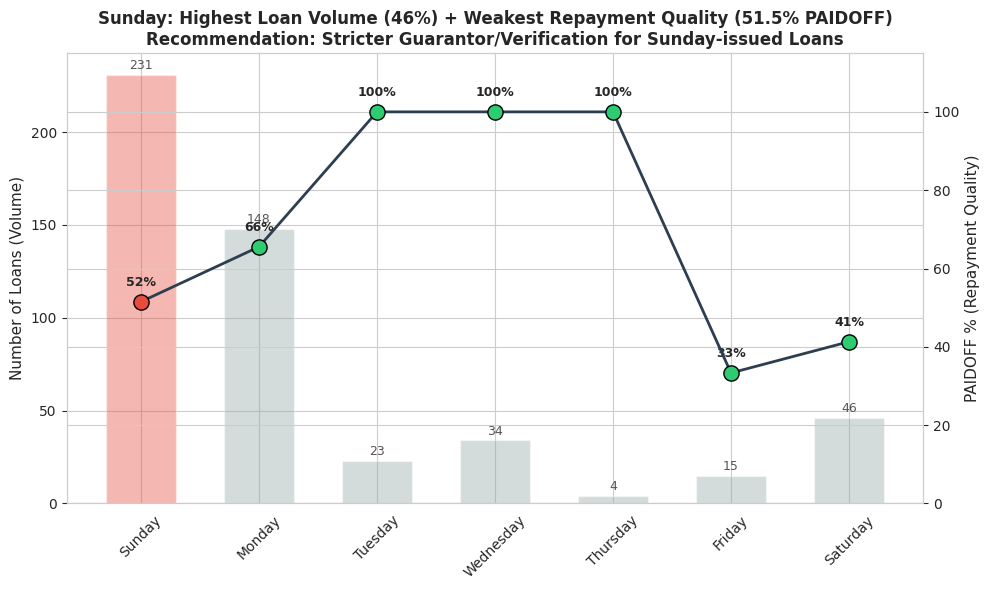

In [118]:
# Sunday: Highest Volume + Weakest Repayment Quality (Combined Risk Finding)
weekday_risk = df.groupby('weekday')['loan_status'].apply(
    lambda x: (x == 'PAIDOFF').sum() / len(x) * 100
).reindex(['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'])

weekday_count = df['weekday'].value_counts().reindex(
    ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'])

colors = ['#e74c3c' if day == 'Sunday' else '#95a5a6' for day in weekday_risk.index]

fig, ax1 = plt.subplots(figsize=(10,6))
bars = ax1.bar(weekday_risk.index, weekday_count.values, color=colors, alpha=0.4, width=0.6)
ax1.set_ylabel('Number of Loans (Volume)', fontsize=11)
for c, v in zip(bars, weekday_count.values):
    ax1.text(c.get_x()+c.get_width()/2, v+3, f'{v}', ha='center', fontsize=9, color='#555')

ax2 = ax1.twinx()
line_colors = ['#e74c3c' if day == 'Sunday' else '#2ecc71' for day in weekday_risk.index]
ax2.plot(weekday_risk.index, weekday_risk.values, color='#2c3e50', marker='o', linewidth=2, zorder=5)
for i, (day, val) in enumerate(zip(weekday_risk.index, weekday_risk.values)):
    dot_color = '#e74c3c' if day == 'Sunday' else '#2ecc71'
    ax2.scatter(i, val, color=dot_color, s=120, zorder=6, edgecolor='black')
    ax2.text(i, val+4, f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylabel('PAIDOFF % (Repayment Quality)', fontsize=11)
ax2.set_ylim(0, 115)

plt.title('Sunday: Highest Loan Volume (46%) + Weakest Repayment Quality (51.5% PAIDOFF)\nRecommendation: Stricter Guarantor/Verification for Sunday-issued Loans',
          fontsize=12, fontweight='bold')
ax1.set_xticklabels(weekday_risk.index, rotation=45)
plt.tight_layout()
plt.show()

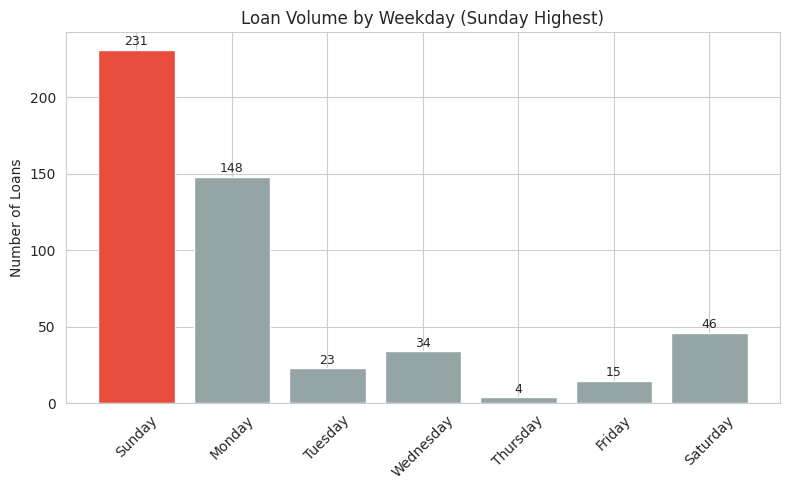

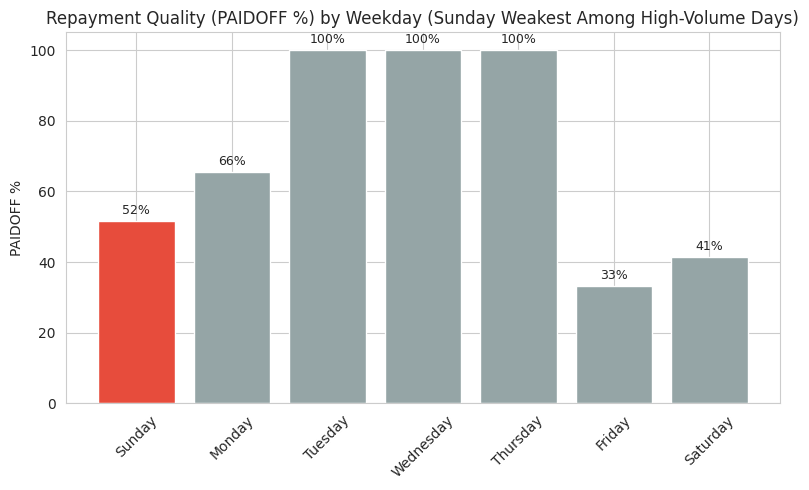

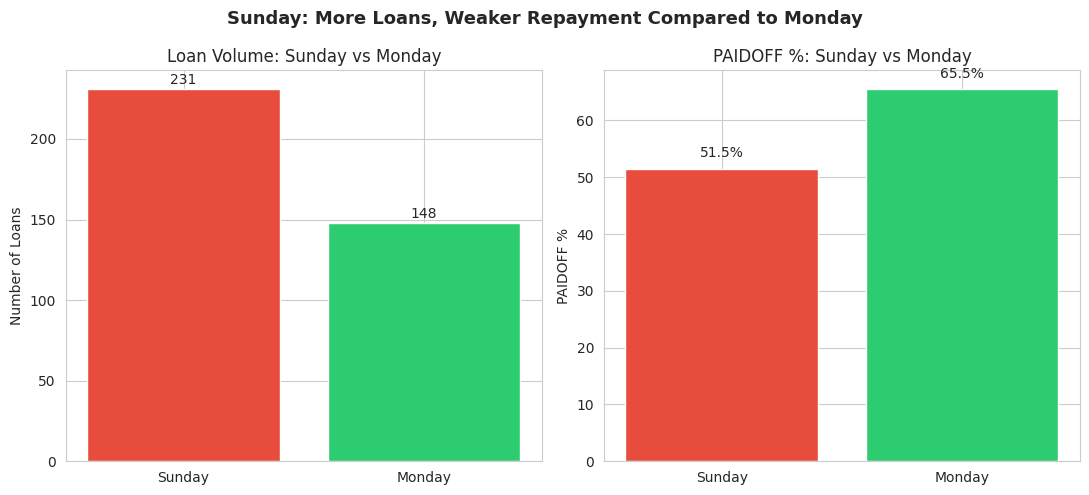

In [119]:
weekday_risk = df.groupby('weekday')['loan_status'].apply(
    lambda x: (x == 'PAIDOFF').sum() / len(x) * 100
).reindex(['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'])

weekday_count = df['weekday'].value_counts().reindex(
    ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'])

colors = ['#e74c3c' if day == 'Sunday' else '#95a5a6' for day in weekday_risk.index]

# Graph 1: Simple bar chart - Loan Volume by Weekday
plt.figure(figsize=(8,5))
bars = plt.bar(weekday_count.index, weekday_count.values, color=colors)
plt.title('Loan Volume by Weekday (Sunday Highest)')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45)
for c in bars:
    plt.text(c.get_x()+c.get_width()/2, c.get_height()+3, f'{int(c.get_height())}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Graph 2: Simple bar chart - PAIDOFF % by Weekday
plt.figure(figsize=(8,5))
bars2 = plt.bar(weekday_risk.index, weekday_risk.values, color=colors)
plt.title('Repayment Quality (PAIDOFF %) by Weekday (Sunday Weakest Among High-Volume Days)')
plt.ylabel('PAIDOFF %')
plt.xticks(rotation=45)
for c in bars2:
    plt.text(c.get_x()+c.get_width()/2, c.get_height()+2, f'{c.get_height():.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Graph 3: Side-by-side comparison - Sunday vs Monday vs Rest
comparison = pd.DataFrame({
    'Volume': weekday_count,
    'PAIDOFF %': weekday_risk
})
highlight = comparison.loc[['Sunday', 'Monday']]

fig, axes = plt.subplots(1, 2, figsize=(11,5))
axes[0].bar(highlight.index, highlight['Volume'], color=['#e74c3c','#2ecc71'])
axes[0].set_title('Loan Volume: Sunday vs Monday')
axes[0].set_ylabel('Number of Loans')
for i, v in enumerate(highlight['Volume']):
    axes[0].text(i, v+3, f'{v}', ha='center', fontsize=10)

axes[1].bar(highlight.index, highlight['PAIDOFF %'], color=['#e74c3c','#2ecc71'])
axes[1].set_title('PAIDOFF %: Sunday vs Monday')
axes[1].set_ylabel('PAIDOFF %')
for i, v in enumerate(highlight['PAIDOFF %']):
    axes[1].text(i, v+2, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Sunday: More Loans, Weaker Repayment Compared to Monday', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()